# RL vs No-RL: Fresh Plan & Buffer Max 曲线对比

D4-v7 所有配对运行 (MAIN=有RL, B4=无RL) 的逐迭代 fresh_reward_mean 和 buffer_max 变化曲线。

In [1]:
import json, os
import matplotlib.pyplot as plt
import numpy as np

base = "/home/silas/co-scientist-project/projects/grant_proposal/runs"

def load_iter_summary(run_name):
    path = os.path.join(base, run_name, "train", "iter_summary.jsonl")
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return [json.loads(l) for l in f]

# D4-v7 per-goal paired runs (25 iters each)
goal_pairs = [
    ("01_foundopt", "d4v7_01_foundopt"),
    ("02_foundational_rl", "d4v7_02_foundational_rl"),
    ("03_probabilistic_ai", "d4v7_03_probabilistic_ai"),
    ("04_trustworthy_ai", "d4v7_04_trustworthy_ai"),
    ("05_causal_healthcare", "d4v7_05_causal_healthcare"),
    ("06_neurosymbolic", "d4v7_06_neurosymbolic"),
    ("07_chemo_toxicity", "d4v7_07_chemo_toxicity"),
    ("08_ecosystem_dynamics", "d4v7_08_ecosystem_dynamics"),
]

data = {}
for label, prefix in goal_pairs:
    main = load_iter_summary(f"2026_04_20_{prefix}_MAIN")
    b4 = load_iter_summary(f"2026_04_20_{prefix}_B4")
    if main and b4:
        data[label] = {"MAIN": main, "B4": b4}

print(f"Loaded {len(data)} goal pairs:")
for g in data:
    print(f"  {g}: MAIN={len(data[g]['MAIN'])} iters, B4={len(data[g]['B4'])} iters")

Loaded 8 goal pairs:
  01_foundopt: MAIN=25 iters, B4=25 iters
  02_foundational_rl: MAIN=25 iters, B4=25 iters
  03_probabilistic_ai: MAIN=16 iters, B4=16 iters
  04_trustworthy_ai: MAIN=17 iters, B4=16 iters
  05_causal_healthcare: MAIN=25 iters, B4=25 iters
  06_neurosymbolic: MAIN=25 iters, B4=25 iters
  07_chemo_toxicity: MAIN=25 iters, B4=25 iters
  08_ecosystem_dynamics: MAIN=25 iters, B4=25 iters


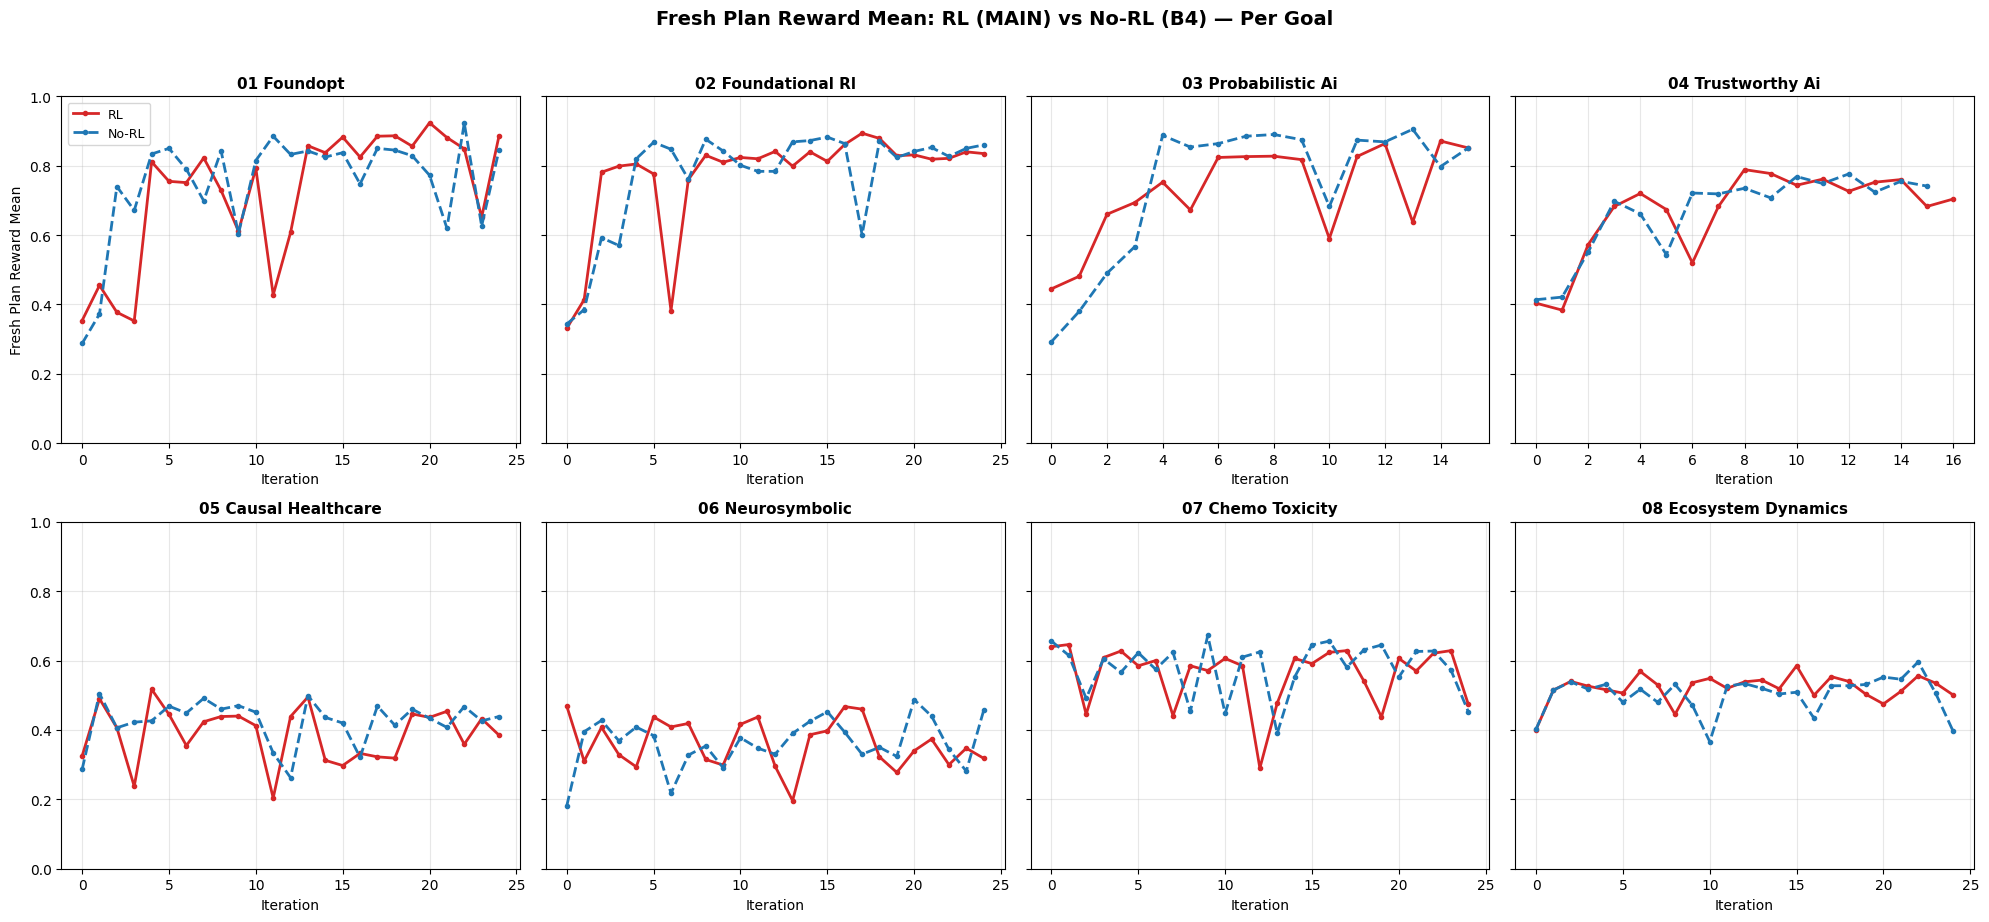

In [2]:
# --- Per-goal: Fresh Plan Mean 曲线 ---
fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey=True)
axes = axes.flatten()

for idx, (goal, runs) in enumerate(data.items()):
    ax = axes[idx]
    for cond, color, ls in [("MAIN", "#d62728", "-"), ("B4", "#1f77b4", "--")]:
        iters = [s["iter"] for s in runs[cond]]
        fresh = [s["fresh/reward_mean"] for s in runs[cond]]
        label = f"{'RL' if cond=='MAIN' else 'No-RL'}"
        ax.plot(iters, fresh, color=color, ls=ls, lw=2, marker="o", ms=3, label=label)
    ax.set_title(goal.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("Iteration")
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.set_ylabel("Fresh Plan Reward Mean")
        ax.legend(fontsize=9)

fig.suptitle("Fresh Plan Reward Mean: RL (MAIN) vs No-RL (B4) — Per Goal", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

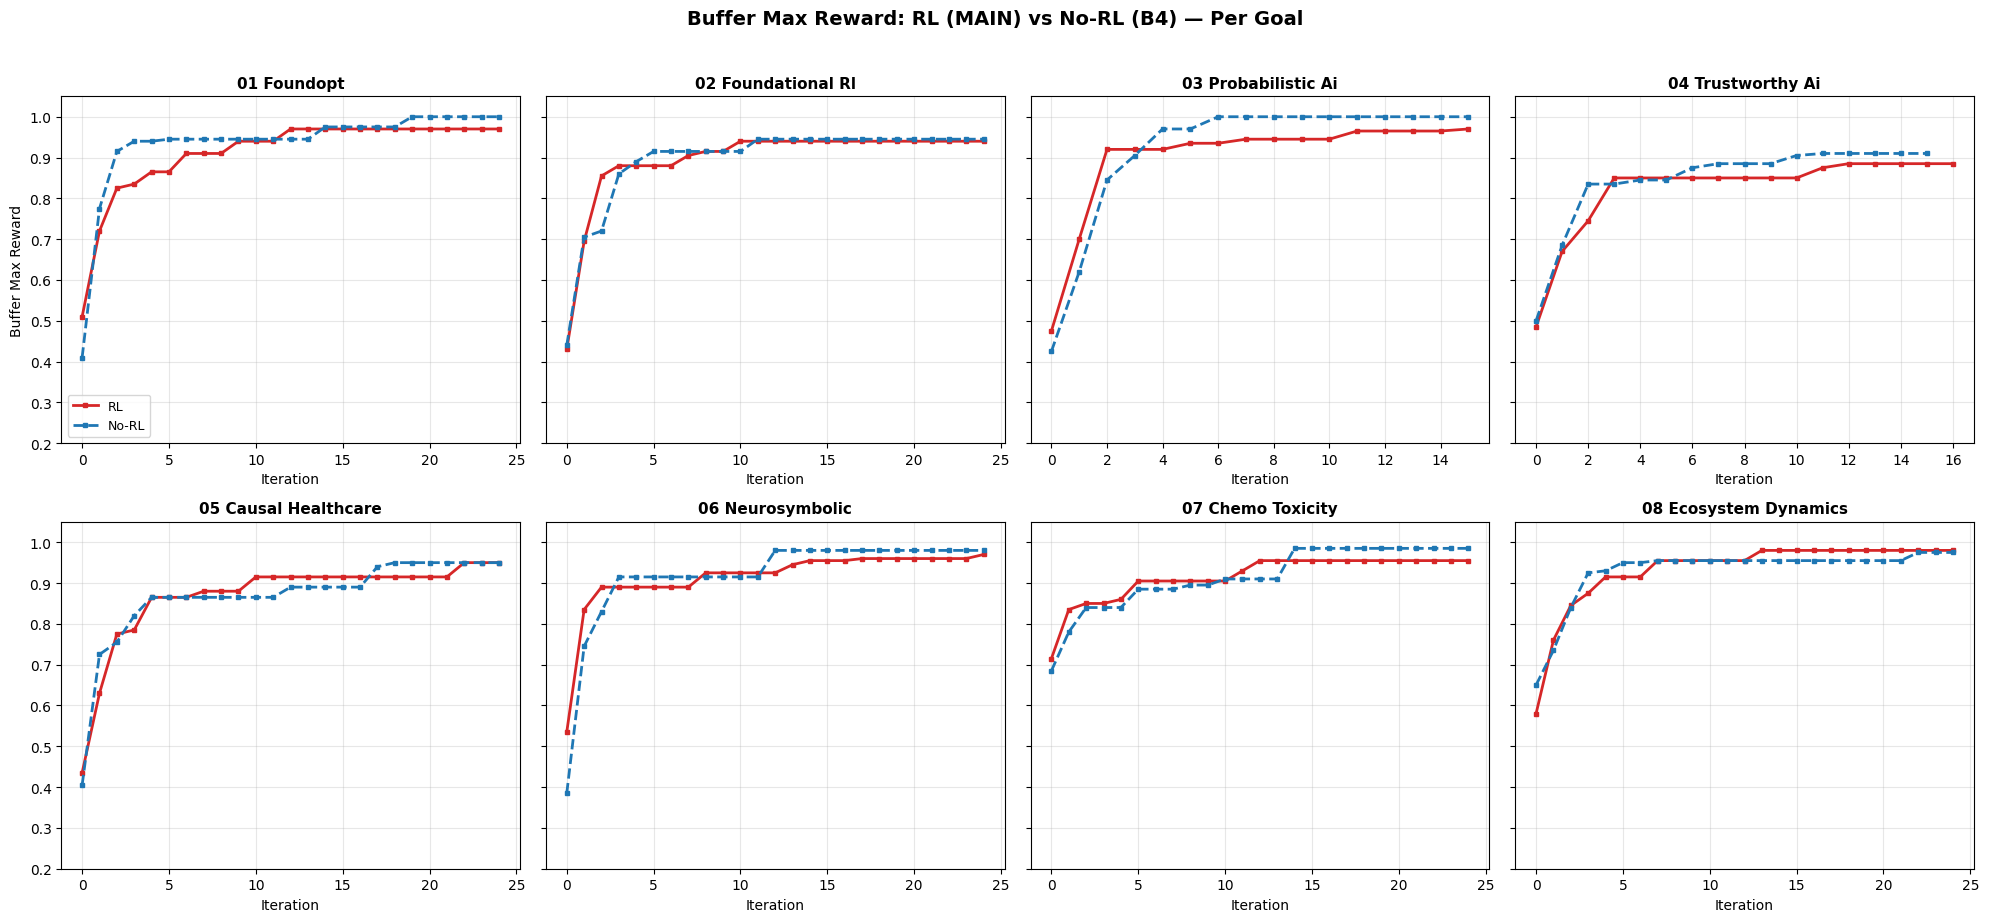

In [3]:
# --- Per-goal: Buffer Max 曲线 ---
fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey=True)
axes = axes.flatten()

for idx, (goal, runs) in enumerate(data.items()):
    ax = axes[idx]
    for cond, color, ls in [("MAIN", "#d62728", "-"), ("B4", "#1f77b4", "--")]:
        iters = [s["iter"] for s in runs[cond]]
        buf_max = [s["reward/buffer_max"] for s in runs[cond]]
        label = f"{'RL' if cond=='MAIN' else 'No-RL'}"
        ax.plot(iters, buf_max, color=color, ls=ls, lw=2, marker="s", ms=3, label=label)
    ax.set_title(goal.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("Iteration")
    ax.set_ylim(0.2, 1.05)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.set_ylabel("Buffer Max Reward")
        ax.legend(fontsize=9)

fig.suptitle("Buffer Max Reward: RL (MAIN) vs No-RL (B4) — Per Goal", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

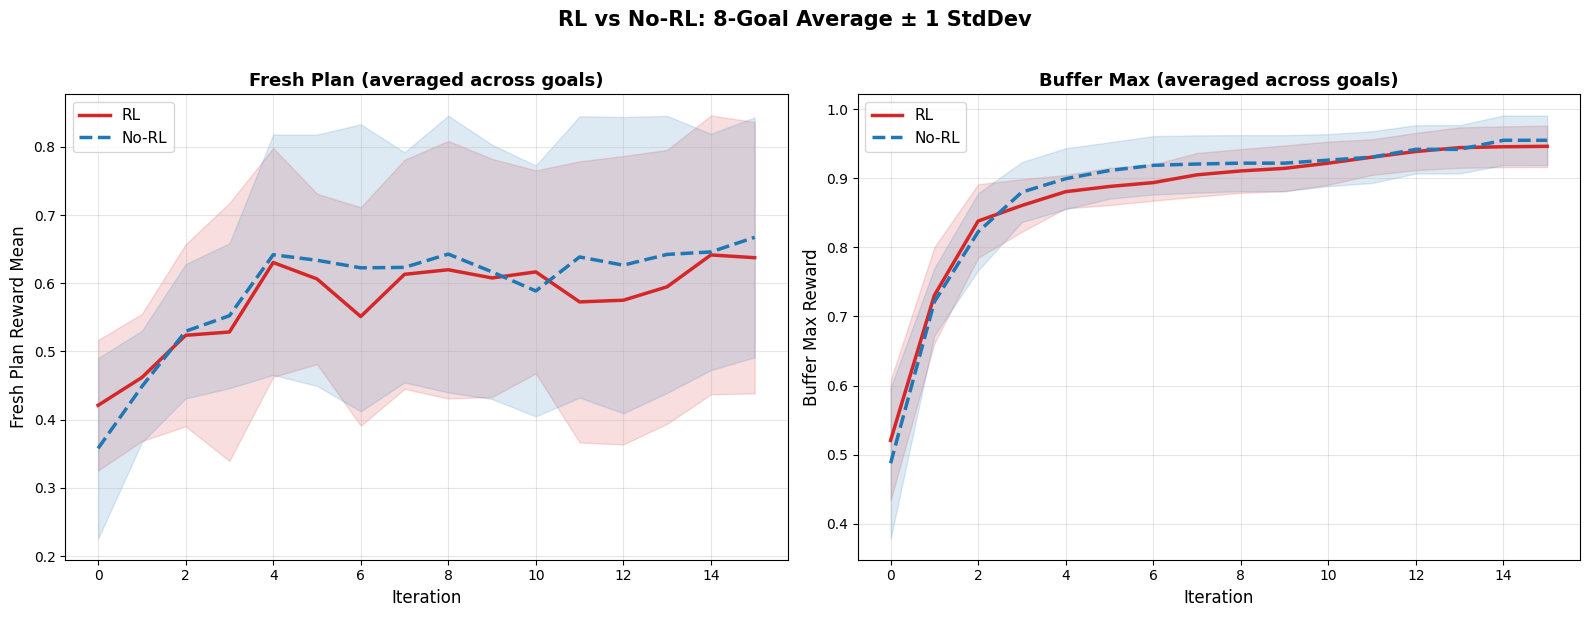

In [4]:
# --- 聚合曲线: 所有目标平均 (只取共同迭代范围) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for metric, ax, ylabel, title in [
    ("fresh/reward_mean", ax1, "Fresh Plan Reward Mean", "Fresh Plan (averaged across goals)"),
    ("reward/buffer_max", ax2, "Buffer Max Reward", "Buffer Max (averaged across goals)"),
]:
    for cond, color, ls, label in [("MAIN", "#d62728", "-", "RL"), ("B4", "#1f77b4", "--", "No-RL")]:
        # Find common iteration range
        min_len = min(len(data[g][cond]) for g in data)
        all_curves = []
        for g in data:
            vals = [data[g][cond][i][metric] for i in range(min_len)]
            all_curves.append(vals)
        all_curves = np.array(all_curves)
        mean = all_curves.mean(axis=0)
        std = all_curves.std(axis=0)
        iters = list(range(min_len))
        
        ax.plot(iters, mean, color=color, ls=ls, lw=2.5, label=label)
        ax.fill_between(iters, mean - std, mean + std, color=color, alpha=0.15)
    
    ax.set_xlabel("Iteration", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

fig.suptitle("RL vs No-RL: 8-Goal Average ± 1 StdDev", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# --- 数值汇总表 ---
print(f"{'Goal':<28s} {'Fresh(RL)':<12s} {'Fresh(B4)':<12s} {'Δfresh':<10s} {'BufMax(RL)':<12s} {'BufMax(B4)':<12s} {'Δbuf':<10s}")
print("-" * 96)

fresh_deltas = []
buf_deltas = []

for goal, runs in data.items():
    # Use last 5 iters average for fresh, and final buf_max
    min_len = min(len(runs["MAIN"]), len(runs["B4"]))
    window = min(5, min_len)
    
    fresh_rl = np.mean([runs["MAIN"][i]["fresh/reward_mean"] for i in range(min_len - window, min_len)])
    fresh_b4 = np.mean([runs["B4"][i]["fresh/reward_mean"] for i in range(min_len - window, min_len)])
    buf_rl = runs["MAIN"][min_len - 1]["reward/buffer_max"]
    buf_b4 = runs["B4"][min_len - 1]["reward/buffer_max"]
    
    df = fresh_rl - fresh_b4
    db = buf_rl - buf_b4
    fresh_deltas.append(df)
    buf_deltas.append(db)
    
    print(f"{goal:<28s} {fresh_rl:<12.3f} {fresh_b4:<12.3f} {df:+.3f}     {buf_rl:<12.3f} {buf_b4:<12.3f} {db:+.3f}")

print("-" * 96)
print(f"{'MEAN':<28s} {'':12s} {'':12s} {np.mean(fresh_deltas):+.3f}     {'':12s} {'':12s} {np.mean(buf_deltas):+.3f}")
print(f"\nFresh mean last-5 delta: RL - B4 = {np.mean(fresh_deltas):+.3f} ± {np.std(fresh_deltas):.3f}")
print(f"Buffer max final delta:  RL - B4 = {np.mean(buf_deltas):+.3f} ± {np.std(buf_deltas):.3f}")

Goal                         Fresh(RL)    Fresh(B4)    Δfresh     BufMax(RL)   BufMax(B4)   Δbuf      
------------------------------------------------------------------------------------------------
01_foundopt                  0.838        0.757        +0.081     0.970        1.000        -0.030
02_foundational_rl           0.829        0.846        -0.017     0.940        0.945        -0.005
03_probabilistic_ai          0.810        0.859        -0.049     0.970        1.000        -0.030
04_trustworthy_ai            0.736        0.749        -0.012     0.885        0.910        -0.025
05_causal_healthcare         0.413        0.435        -0.022     0.950        0.950        +0.000
06_neurosymbolic             0.336        0.402        -0.066     0.970        0.980        -0.010
07_chemo_toxicity            0.580        0.566        +0.014     0.955        0.985        -0.030
08_ecosystem_dynamics        0.516        0.520        -0.004     0.980        0.975        +0.005
--------

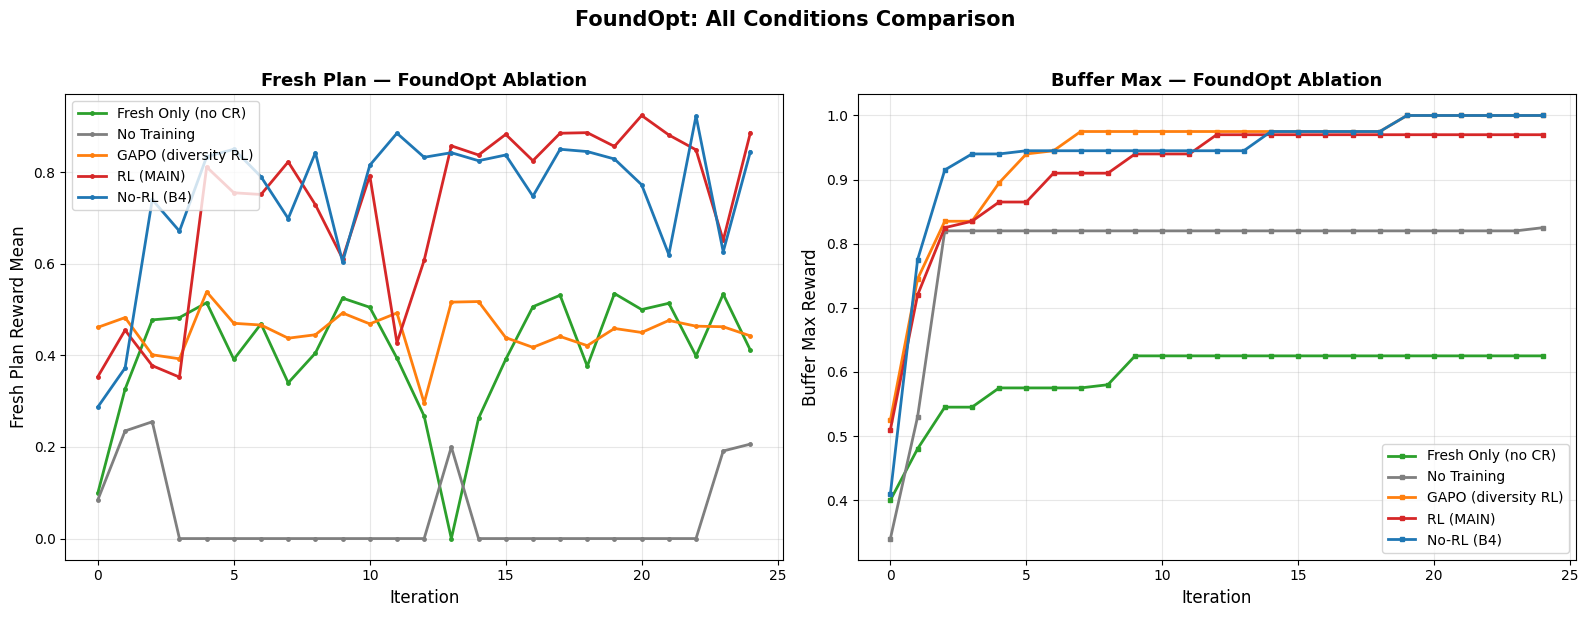

In [6]:
# --- 额外: 也加载 ablation 和 special runs (A_fresh_only, GAPO) ---
special_runs = {
    "A_fresh_only": "2026_04_20_d4v7_A_fresh_only",
    "B4_no_training": "2026_04_20_d4v7_B4_no_training",
    "GAPO": "2026_04_21_gapo_foundopt",
    "foundopt_MAIN": "2026_04_20_d4v7_01_foundopt_MAIN",
    "foundopt_B4": "2026_04_20_d4v7_01_foundopt_B4",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = {"foundopt_MAIN": "#d62728", "foundopt_B4": "#1f77b4", "A_fresh_only": "#2ca02c", 
          "B4_no_training": "#7f7f7f", "GAPO": "#ff7f0e"}
labels = {"foundopt_MAIN": "RL (MAIN)", "foundopt_B4": "No-RL (B4)", "A_fresh_only": "Fresh Only (no CR)", 
          "B4_no_training": "No Training", "GAPO": "GAPO (diversity RL)"}

for name, run_name in special_runs.items():
    s = load_iter_summary(run_name)
    if not s:
        continue
    iters = [x["iter"] for x in s]
    fresh = [x["fresh/reward_mean"] for x in s]
    buf_max = [x["reward/buffer_max"] for x in s]
    
    ax1.plot(iters, fresh, color=colors[name], lw=2, label=labels[name], marker="o", ms=2.5)
    ax2.plot(iters, buf_max, color=colors[name], lw=2, label=labels[name], marker="s", ms=2.5)

for ax, ylabel, title in [(ax1, "Fresh Plan Reward Mean", "Fresh Plan — FoundOpt Ablation"),
                           (ax2, "Buffer Max Reward", "Buffer Max — FoundOpt Ablation")]:
    ax.set_xlabel("Iteration", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle("FoundOpt: All Conditions Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()